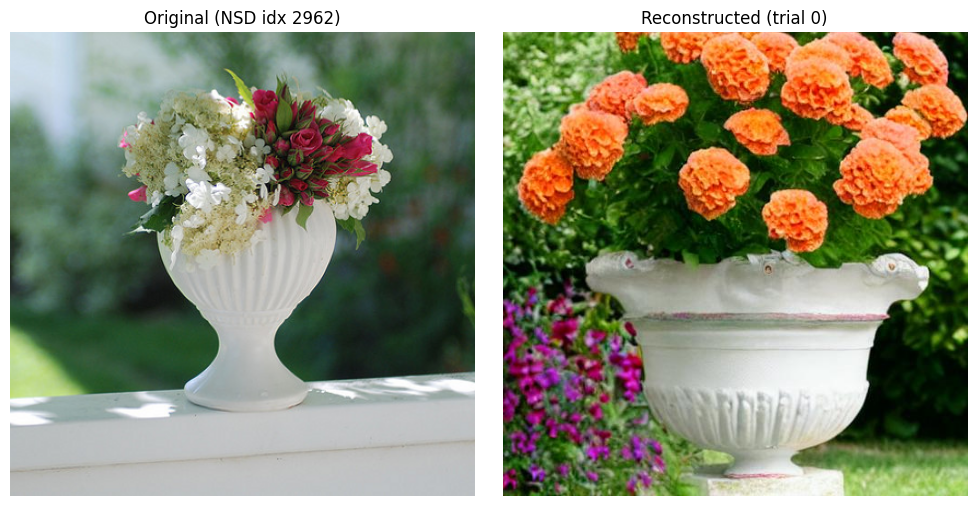

In [1]:
# --- Config ---
idx = 0  # trial / stimulus index you decoded
nsd_root = "data/nsddata"
processed_dir = "data/processed"
recon_dir = "./decoded"          # or ./reconstructions if you changed it
recon_prefix = ""               # e.g. "trial_" if you used --save_prefix

# ----------------

import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Load NSD id mapping (same one used by create_pseudo_txt.py)
processed_dir = Path(processed_dir)
nsd_ids = np.load(processed_dir / "mappings" / "subj01_nsd_image_ids.npy")

# Load original NSD stimulus
stimuli_path = Path(nsd_root) / "stimuli" / "nsd" / "nsd_stimuli.hdf5"
with h5py.File(stimuli_path, "r") as f:
    nsd_idx = int(nsd_ids[idx])
    original = f["imgBrick"][nsd_idx]

original_img = Image.fromarray(original).convert("RGB")

# Load reconstructed image
recon_path = Path(recon_dir) / f"{recon_prefix}{idx}.jpg"
recon_img = Image.open(recon_path).convert("RGB")

# Plot side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Original (NSD idx {nsd_idx})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(recon_img)
plt.title(f"Reconstructed (trial {idx})")
plt.axis("off")

plt.tight_layout()
plt.show()


# MOSAIC

In [ ]:
from pathlib import Path

from decoder import init_decoder, decode_one

# -------- paths --------
embeddings_path = "data/processed/embeddings/subj01_text_token_embeddings.npy"
pretrained_path = "CompVis/stable-diffusion-v1-4"
output_dir = "./decoded"

# -------- experiment setup --------
indices = list(range(10))      # 10 classes / trials
seeds = [0, 1, 2, 3, 4]        # 5 reconstructions each

guidance_scale = 8.5
num_steps = 50
device = "cuda"

Path(output_dir).mkdir(exist_ok=True)

pipe, embeddings = init_decoder(pretrained_path, embeddings_path, device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
import os
from PIL import Image
import torch

@torch.no_grad()
def decode_batch(
    pipe,
    embeddings,
    indices,
    seed,
    guidance_scale,
    num_steps,
    output_dir,
):
    prompt_embeds = embeddings[indices]   # [B,77,768]

    generator = torch.Generator(device=pipe.device).manual_seed(seed)

    images = pipe(
        prompt=None,
        prompt_embeds=prompt_embeds,
        guidance_scale=guidance_scale,
        num_inference_steps=num_steps,
        generator=generator,
    ).images

    os.makedirs(output_dir, exist_ok=True)

    for idx, img in zip(indices, images):
        img.save(os.path.join(output_dir, f"{idx}_seed{seed}.jpg"))


In [ ]:
for seed in seeds:
    decode_batch(
        pipe,
        embeddings,
        indices,
        seed,
        guidance_scale,
        num_steps,
        output_dir,
    )


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

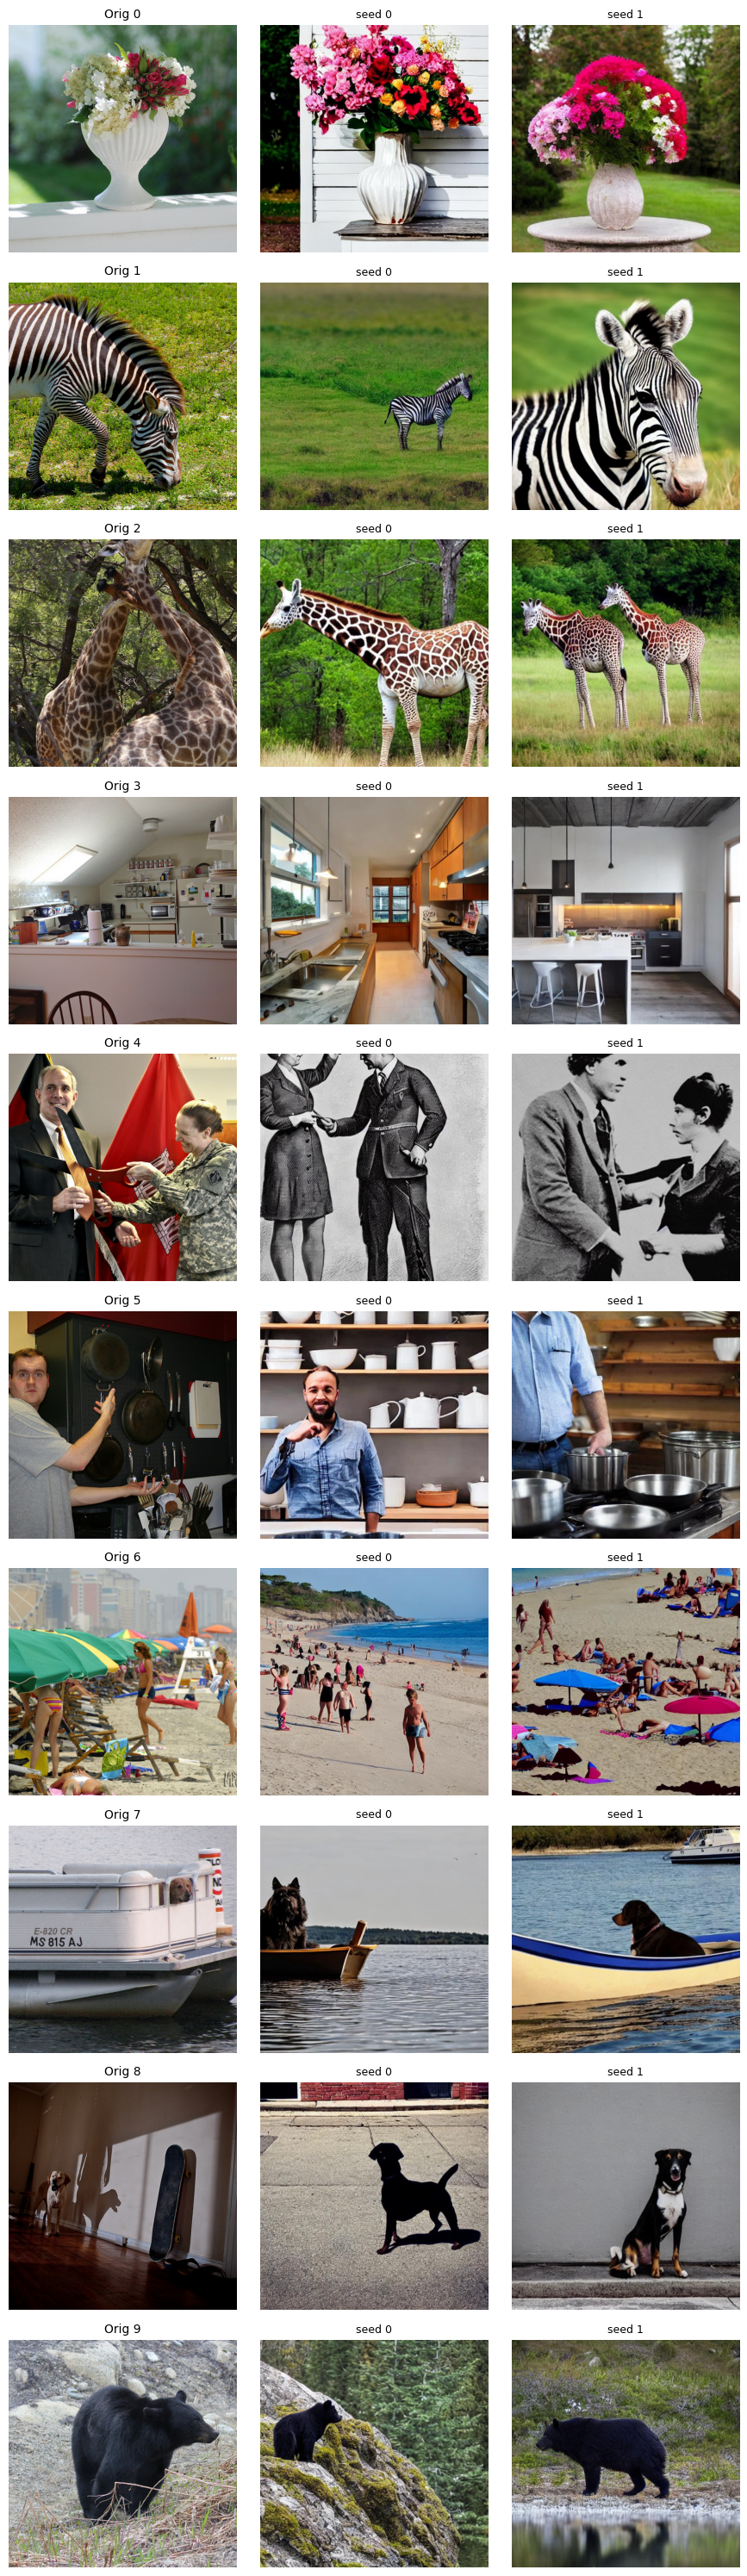

In [1]:
# -------- Config --------
nsd_root = "data/nsddata"
processed_dir = "data/processed"
recon_dir = "./decoded"

num_classes = 10                 # rows
seeds = [0, 1]          # 5 recon columns
indices = list(range(num_classes))  # which trials/classes to visualize

# expected recon filename:
#   {idx}_seed{seed}.jpg
# example: 3_seed2.jpg
# ------------------------

import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path(processed_dir)
recon_dir = Path(recon_dir)

# Load NSD id mapping
nsd_ids = np.load(processed_dir / "mappings" / "subj01_nsd_image_ids.npy")

# Load NSD stimuli once
stimuli_path = Path(nsd_root) / "stimuli" / "nsd" / "nsd_stimuli.hdf5"
nsd_file = h5py.File(stimuli_path, "r")
imgBrick = nsd_file["imgBrick"]

rows = len(indices)
cols = 1 + len(seeds)   # original + 5 recon

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

for r, idx in enumerate(indices):
    nsd_idx = int(nsd_ids[idx])
    original = imgBrick[nsd_idx]
    original_img = Image.fromarray(original).convert("RGB")

    # ---- Original (column 0) ----
    axes[r, 0].imshow(original_img)
    axes[r, 0].set_title(f"Orig {idx}", fontsize=10)
    axes[r, 0].axis("off")

    # ---- Reconstructions ----
    for c, seed in enumerate(seeds):
        recon_path = recon_dir / f"{idx}_seed{seed}.jpg"

        if recon_path.exists():
            recon_img = Image.open(recon_path).convert("RGB")
            axes[r, c + 1].imshow(recon_img)
        else:
            # blank if missing
            axes[r, c + 1].text(0.5, 0.5, "missing",
                                ha="center", va="center")
        axes[r, c + 1].set_title(f"seed {seed}", fontsize=9)
        axes[r, c + 1].axis("off")

plt.tight_layout()
plt.show()

nsd_file.close()
